Number of common APs : 358
['00:04:EA:8E:1C:39', '00:08:9F:7E:73:F6', '00:0B:81:9B:C4:49', '00:40:5A:AF:48:82', '00:40:5A:AF:48:83', '00:40:5A:AF:5D:DA', '00:40:5A:AF:5D:DB', '00:40:5A:AF:68:61', '00:40:5A:AF:68:62', '00:40:5A:AF:68:63', '00:40:5A:AF:7B:2A', '00:40:5A:AF:7B:2B', '00:40:5A:AF:98:B9', '00:40:5A:AF:98:BA', '00:40:5A:AF:98:BB', '00:40:5A:AF:C2:89', '00:40:5A:AF:C2:8A', '00:40:5A:AF:C2:8B', '00:40:5A:AF:CA:39', '00:40:5A:AF:CA:3A', '00:40:5A:AF:CA:3B', '00:40:5A:AF:D0:C1', '00:40:5A:AF:D0:C2', '00:40:5A:AF:D0:C3', '00:40:5A:AF:E1:99', '00:40:5A:AF:E1:9A', '00:40:5A:AF:E1:9B', '02:06:AC:80:61:66', '06:0E:3C:75:B2:B8', '12:06:AC:80:61:66', '12:E8:A7:8C:5F:5D', '1C:39:29:23:98:F4', '1C:39:29:23:99:2A', '1C:39:29:23:99:38', '1C:39:29:23:99:41', '1C:39:29:23:99:45', '1C:39:29:23:99:67', '1C:39:29:23:99:E6', '1C:39:29:23:99:EB', '1C:39:29:23:99:FB', '1C:39:29:23:9A:16', '1C:39:29:23:C5:94', '1C:39:29:28:66:24', '1C:BF:CE:2D:AA:95', '1C:E8:9E:63:97:1C', '1E:39:29:69:36:8D', '1E:39

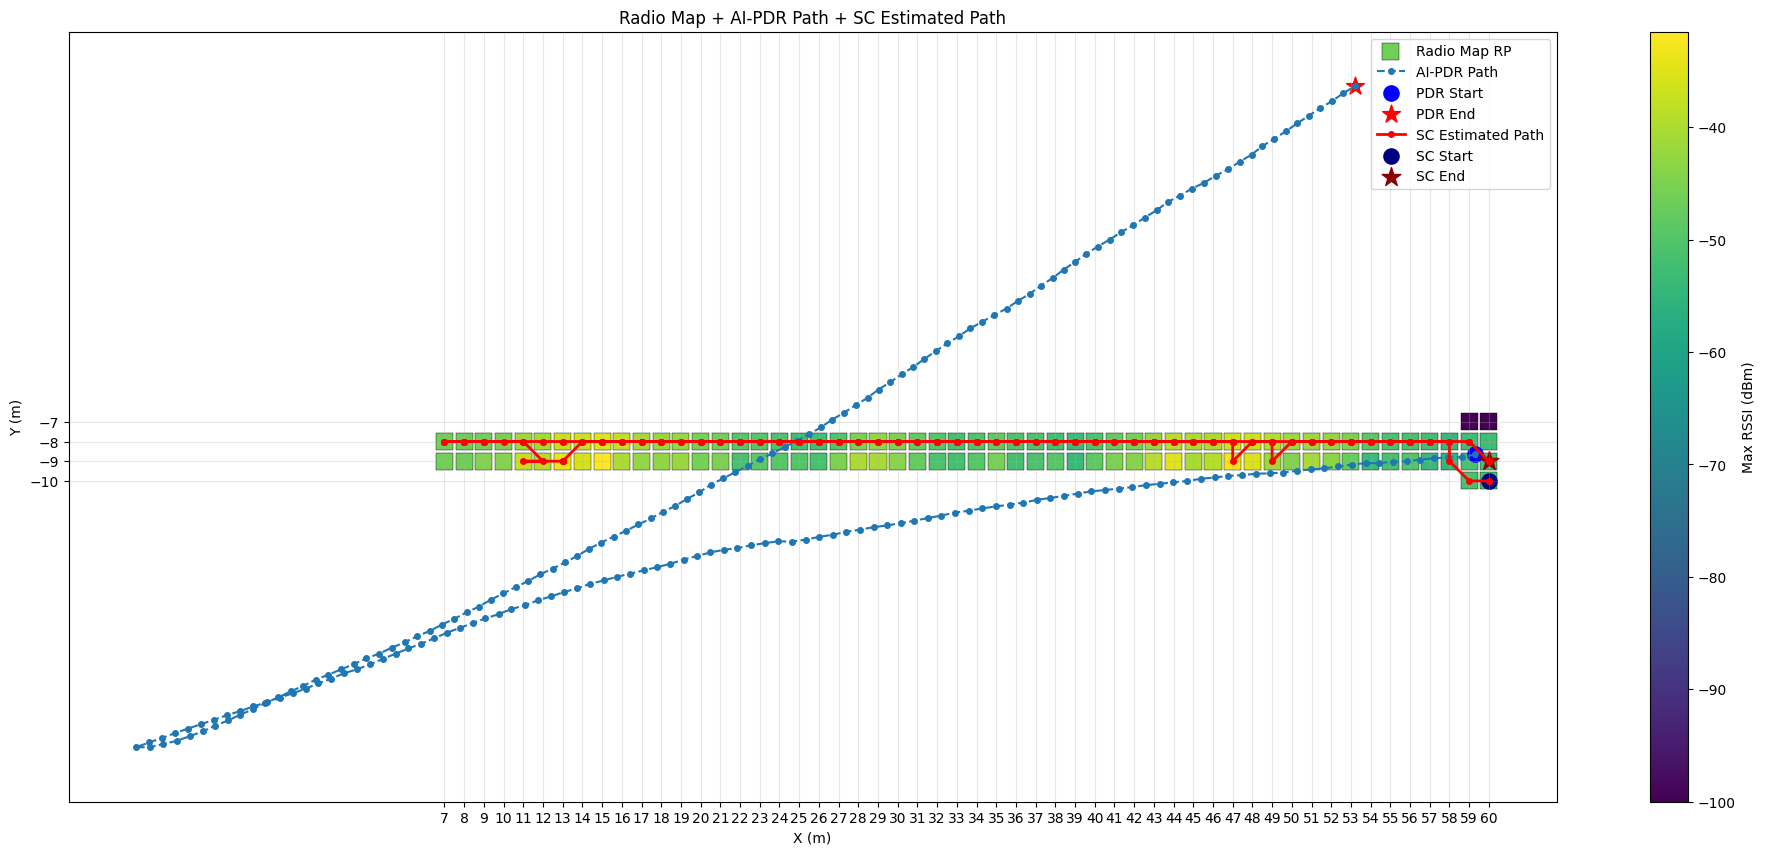

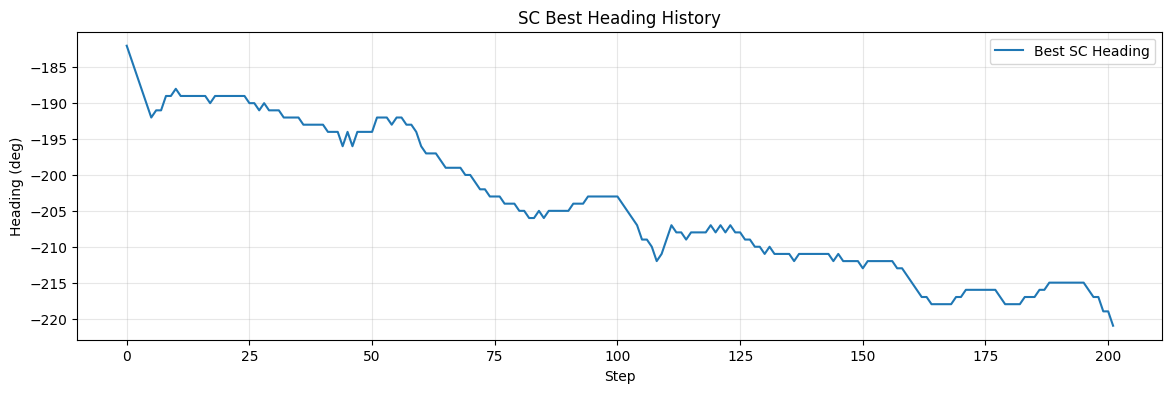

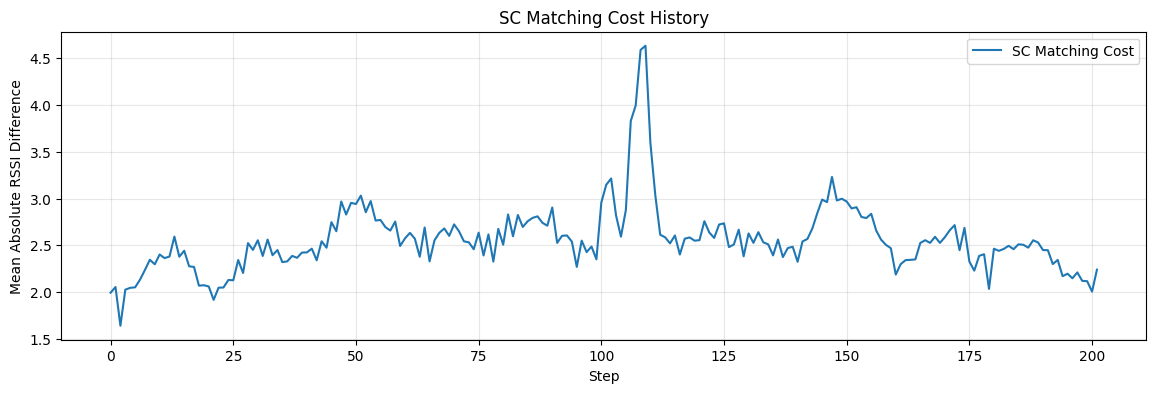

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# ============================================================
# 0. 사용자 설정
# ============================================================
BASE_DIR = os.getcwd()

RADIOMAP_DIR = os.path.join(BASE_DIR, 'radio_map.csv')
PDR_DIR = os.path.join(BASE_DIR, 'temp_data', 'pdr_WiFi.csv')

BUFFER_SIZE = 10
DELTA_HEADING = 1.0

INITIAL_HEADING = -180.0
CURRENT_HEADING = INITIAL_HEADING

# AI-PDR 경로를 radio map 좌표계에 맞춰 보기 위한 이동값
PDR_SHIFT_X = 59.31065546324714
PDR_SHIFT_Y = -8.657145362647874

MISSING_RSSI = -100.0


# ============================================================
# 1. 데이터 로드
# ============================================================
radioMap = pd.read_csv(RADIOMAP_DIR)
pdr = pd.read_csv(PDR_DIR)

pdr_path = pdr[['x', 'y']].to_numpy(dtype=float)


# ============================================================
# 2. 함수 정의
# ============================================================
def rotate_path(path, angle_deg):
    """
    PDR segment를 segment 시작점을 기준으로 회전
    SC 매칭용
    """
    rad = np.deg2rad(angle_deg)
    R = np.array([
        [np.cos(rad), -np.sin(rad)],
        [np.sin(rad),  np.cos(rad)]
    ])

    return (path - path[0]) @ R.T + path[0]


def rotate_coords(coords, angle_deg):
    """
    전체 PDR 경로를 원점 기준으로 회전
    시각화용
    """
    rad = np.deg2rad(angle_deg)
    R = np.array([
        [np.cos(rad), -np.sin(rad)],
        [np.sin(rad),  np.cos(rad)]
    ])

    return coords @ R.T


def generate_single_urs_dynamic(pdr_path, rssi_values, resolution=1.0):
    """
    PDR segment + RSSI sequence를 이용해서 URS 생성
    """
    origin = pdr_path[0].copy()

    def get_cell(pos):
        cell_x = int(np.round((pos[0] - origin[0]) / resolution))
        cell_y = int(np.round((pos[1] - origin[1]) / resolution))
        return cell_x, cell_y

    grid_cells = np.array([get_cell(pos) for pos in pdr_path])

    x_min, x_max = grid_cells[:, 0].min(), grid_cells[:, 0].max()
    y_min, y_max = grid_cells[:, 1].min(), grid_cells[:, 1].max()

    num_aps = rssi_values.shape[1]

    urs = np.full(
        (num_aps, y_max - y_min + 1, x_max - x_min + 1),
        MISSING_RSSI,
        dtype=float
    )

    for i, (gx, gy) in enumerate(grid_cells):
        px = gx - x_min
        py = gy - y_min

        if 0 <= px < urs.shape[2] and 0 <= py < urs.shape[1]:
            urs[:, py, px] = rssi_values[i]

    offset_x = grid_cells[-1][0] - x_min
    offset_y = grid_cells[-1][1] - y_min

    return urs, (offset_x, offset_y), x_min, y_min


def calculate_correlation(urs, radio_map):
    """
    URS와 Radio Map 사이의 SAD 기반 correlation 계산
    """
    best_corr = np.inf
    best_pos = None

    urs_flat = urs.flatten()
    mask = urs_flat > MISSING_RSSI

    H, W = urs.shape[1], urs.shape[2]
    RM_H, RM_W = radio_map.shape[1], radio_map.shape[2]

    # URS가 radio map보다 크면 매칭 불가능
    if H > RM_H or W > RM_W:
        return None, np.inf

    # 유효한 RSSI가 하나도 없으면 매칭 불가능
    if not np.any(mask):
        return None, np.inf

    for i in range(RM_H - H + 1):
        for j in range(RM_W - W + 1):
            seg_flat = radio_map[:, i:i + H, j:j + W].flatten()

            diff = np.mean(np.abs(urs_flat[mask] - seg_flat[mask]))

            if diff < best_corr:
                best_corr = diff
                best_pos = (j, i)

    return best_pos, best_corr


# ============================================================
# 3. 공통 AP 추출
# ============================================================
radio_exclude_cols = {
    'x',
    'y',
    'pixel_x',
    'pixel_y',
    'is_pdr_filled',
    'near_sample_count',
    'linear_filled_ap_count',
    'neighbor_filled_ap_count'
}

pdr_exclude_cols = {
    'x',
    'y',
    'step',
    'time',
    'is_turn'
}

radio_ap_list = [
    c for c in radioMap.columns
    if c not in radio_exclude_cols
]

pdr_ap_list = [
    c for c in pdr.columns
    if c not in pdr_exclude_cols
]

common_aps = sorted(list(set(radio_ap_list) & set(pdr_ap_list)))

print(f"Number of common APs : {len(common_aps)}")
print(common_aps)

if len(common_aps) == 0:
    raise ValueError("radio_map.csv와 pdr_WiFi.csv 사이에 공통 AP가 없습니다.")


# ============================================================
# 4. Radio Map을 3D 배열로 변환
#    shape = AP x Y x X
# ============================================================
x_vals = sorted(radioMap['x'].unique())
y_vals = sorted(radioMap['y'].unique())

num_aps = len(common_aps)
H, W = len(y_vals), len(x_vals)

radio_map = np.full((num_aps, H, W), MISSING_RSSI, dtype=float)

x_to_i = {x: i for i, x in enumerate(x_vals)}
y_to_i = {y: i for i, y in enumerate(y_vals)}

for _, row in radioMap.iterrows():
    xi = x_to_i[row['x']]
    yi = y_to_i[row['y']]

    for k, ap in enumerate(common_aps):
        radio_map[k, yi, xi] = row[ap]


# ============================================================
# 5. PDR RSSI History
# ============================================================
rssi_history = (
    pdr[common_aps]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(MISSING_RSSI)
    .to_numpy(dtype=float)
)


# ============================================================
# 6. SC Main Logic
# ============================================================
estimated = []
best_heading_history = []
best_corr_history = []
temp_headings = []

for step in range(len(pdr_path)):
    s = max(0, step - BUFFER_SIZE + 1)

    seg_pdr = pdr_path[s:step + 1]
    seg_rssi = rssi_history[s:step + 1]

    candidates = []

    heading_candidates = [
        CURRENT_HEADING - DELTA_HEADING * 2,
        CURRENT_HEADING - DELTA_HEADING,
        CURRENT_HEADING,
        CURRENT_HEADING + DELTA_HEADING,
        CURRENT_HEADING + DELTA_HEADING * 2
    ]

    for ang in heading_candidates:
        temp_headings.append(ang)

        rotated = rotate_path(seg_pdr, ang)

        urs, (off_x, off_y), x_min, y_min = generate_single_urs_dynamic(
            rotated,
            seg_rssi
        )

        pos, corr = calculate_correlation(urs, radio_map)

        # 매칭 불가능한 후보는 제외
        if pos is None:
            continue

        j, i = pos

        candidates.append(
            (
                corr,
                ang,
                j,
                i,
                off_x,
                off_y,
                x_min,
                y_min,
                urs
            )
        )

    # 유효 후보가 없는 경우
    if len(candidates) == 0:
        print(f"[WARN] step {step}: 유효한 SC 후보 없음")

        if len(estimated) > 0:
            estimated.append(estimated[-1])
        else:
            estimated.append((np.nan, np.nan))

        best_heading_history.append(CURRENT_HEADING)
        best_corr_history.append(np.nan)

        continue

    # 최적 후보 선택
    best = min(candidates, key=lambda x: x[0])

    (
        corr,
        best_angle,
        best_j,
        best_i,
        off_x,
        off_y,
        best_x_min,
        best_y_min,
        best_urs
    ) = best

    est_j = best_j + off_x
    est_i = best_i + off_y

    # 인덱스 범위 체크
    if not (0 <= est_j < len(x_vals) and 0 <= est_i < len(y_vals)):
        print(f"[WARN] step {step}: estimated index out of range")
        print("est_j, est_i:", est_j, est_i)
        print("len(x_vals), len(y_vals):", len(x_vals), len(y_vals))

        if len(estimated) > 0:
            estimated.append(estimated[-1])
        else:
            estimated.append((np.nan, np.nan))

        best_heading_history.append(CURRENT_HEADING)
        best_corr_history.append(np.nan)

        continue

    ex = x_vals[est_j]
    ey = y_vals[est_i]

    estimated.append((ex, ey))

    # 중요: 다음 step에서 사용할 heading 업데이트
    CURRENT_HEADING = best_angle

    best_heading_history.append(best_angle)
    best_corr_history.append(corr)


estimated = np.array(estimated, dtype=float)

print("SC estimated path shape:", estimated.shape)


# ============================================================
# 7. AI-PDR 경로를 Radio Map 좌표계에 맞게 회전 + 이동
# ============================================================
pdr_path_rotated = rotate_coords(pdr_path, INITIAL_HEADING)

pdr_path_aligned = pdr_path_rotated.copy()
pdr_path_aligned[:, 0] += PDR_SHIFT_X
pdr_path_aligned[:, 1] += PDR_SHIFT_Y


# ============================================================
# 8. Radio Map + AI-PDR Path + SC Path 시각화
# ============================================================
coords = radioMap[['x', 'y']].to_numpy(dtype=float)
max_rssi = radioMap[common_aps].max(axis=1).to_numpy(dtype=float)

valid_est_mask = ~np.isnan(estimated[:, 0]) & ~np.isnan(estimated[:, 1])
estimated_valid = estimated[valid_est_mask]

fig, ax = plt.subplots(figsize=(24, 10))

# ---------------- Radio Map Background ----------------
sc = ax.scatter(
    coords[:, 0],
    coords[:, 1],
    c=max_rssi,
    cmap="viridis",
    s=150,
    marker="s",
    edgecolor="k",
    linewidth=0.3,
    label="Radio Map RP"
)

fig.colorbar(sc, ax=ax, label="Max RSSI (dBm)")


# ---------------- AI-PDR Path ----------------
ax.plot(
    pdr_path_aligned[:, 0],
    pdr_path_aligned[:, 1],
    "o--",
    markersize=4,
    linewidth=1.5,
    label="AI-PDR Path"
)

ax.scatter(
    pdr_path_aligned[0, 0],
    pdr_path_aligned[0, 1],
    c="blue",
    marker="o",
    s=120,
    label="PDR Start"
)

ax.scatter(
    pdr_path_aligned[-1, 0],
    pdr_path_aligned[-1, 1],
    c="red",
    marker="*",
    s=180,
    label="PDR End"
)


# ---------------- SC Estimated Path ----------------
if len(estimated_valid) > 0:
    ax.plot(
        estimated_valid[:, 0],
        estimated_valid[:, 1],
        "r.-",
        markersize=8,
        linewidth=2,
        label="SC Estimated Path"
    )

    ax.scatter(
        estimated_valid[0, 0],
        estimated_valid[0, 1],
        c="navy",
        marker="o",
        s=120,
        label="SC Start"
    )

    ax.scatter(
        estimated_valid[-1, 0],
        estimated_valid[-1, 1],
        c="darkred",
        marker="*",
        s=200,
        label="SC End"
    )


# ---------------- Plot Setting ----------------
ax.set_title("Radio Map + AI-PDR Path + SC Estimated Path")
ax.set_xlabel("X (m)")
ax.set_ylabel("Y (m)")

ax.set_xticks(
    np.arange(
        np.floor(coords[:, 0].min()),
        np.ceil(coords[:, 0].max()) + 1,
        1
    )
)

ax.set_yticks(
    np.arange(
        np.floor(coords[:, 1].min()),
        np.ceil(coords[:, 1].max()) + 1,
        1
    )
)

ax.grid(True, alpha=0.3)
ax.axis("equal")
ax.legend(loc="upper right")

plt.show()


# ============================================================
# 9. 선택 사항: SC Heading 변화 확인
# ============================================================
plt.figure(figsize=(14, 4))
plt.plot(best_heading_history, label="Best SC Heading")
plt.xlabel("Step")
plt.ylabel("Heading (deg)")
plt.title("SC Best Heading History")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


# ============================================================
# 10. 선택 사항: SC Correlation Cost 확인
# ============================================================
plt.figure(figsize=(14, 4))
plt.plot(best_corr_history, label="SC Matching Cost")
plt.xlabel("Step")
plt.ylabel("Mean Absolute RSSI Difference")
plt.title("SC Matching Cost History")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

[CALIB]
image_path: c:\Users\kimbo\NNL\workspace\vscode_workspace\고속수집기_라디오맵\data/공학관3층_동측_도면.png
m_per_px: 0.04666666666666667
px_per_m: 21.428571428571427
flip_y_before_save: True


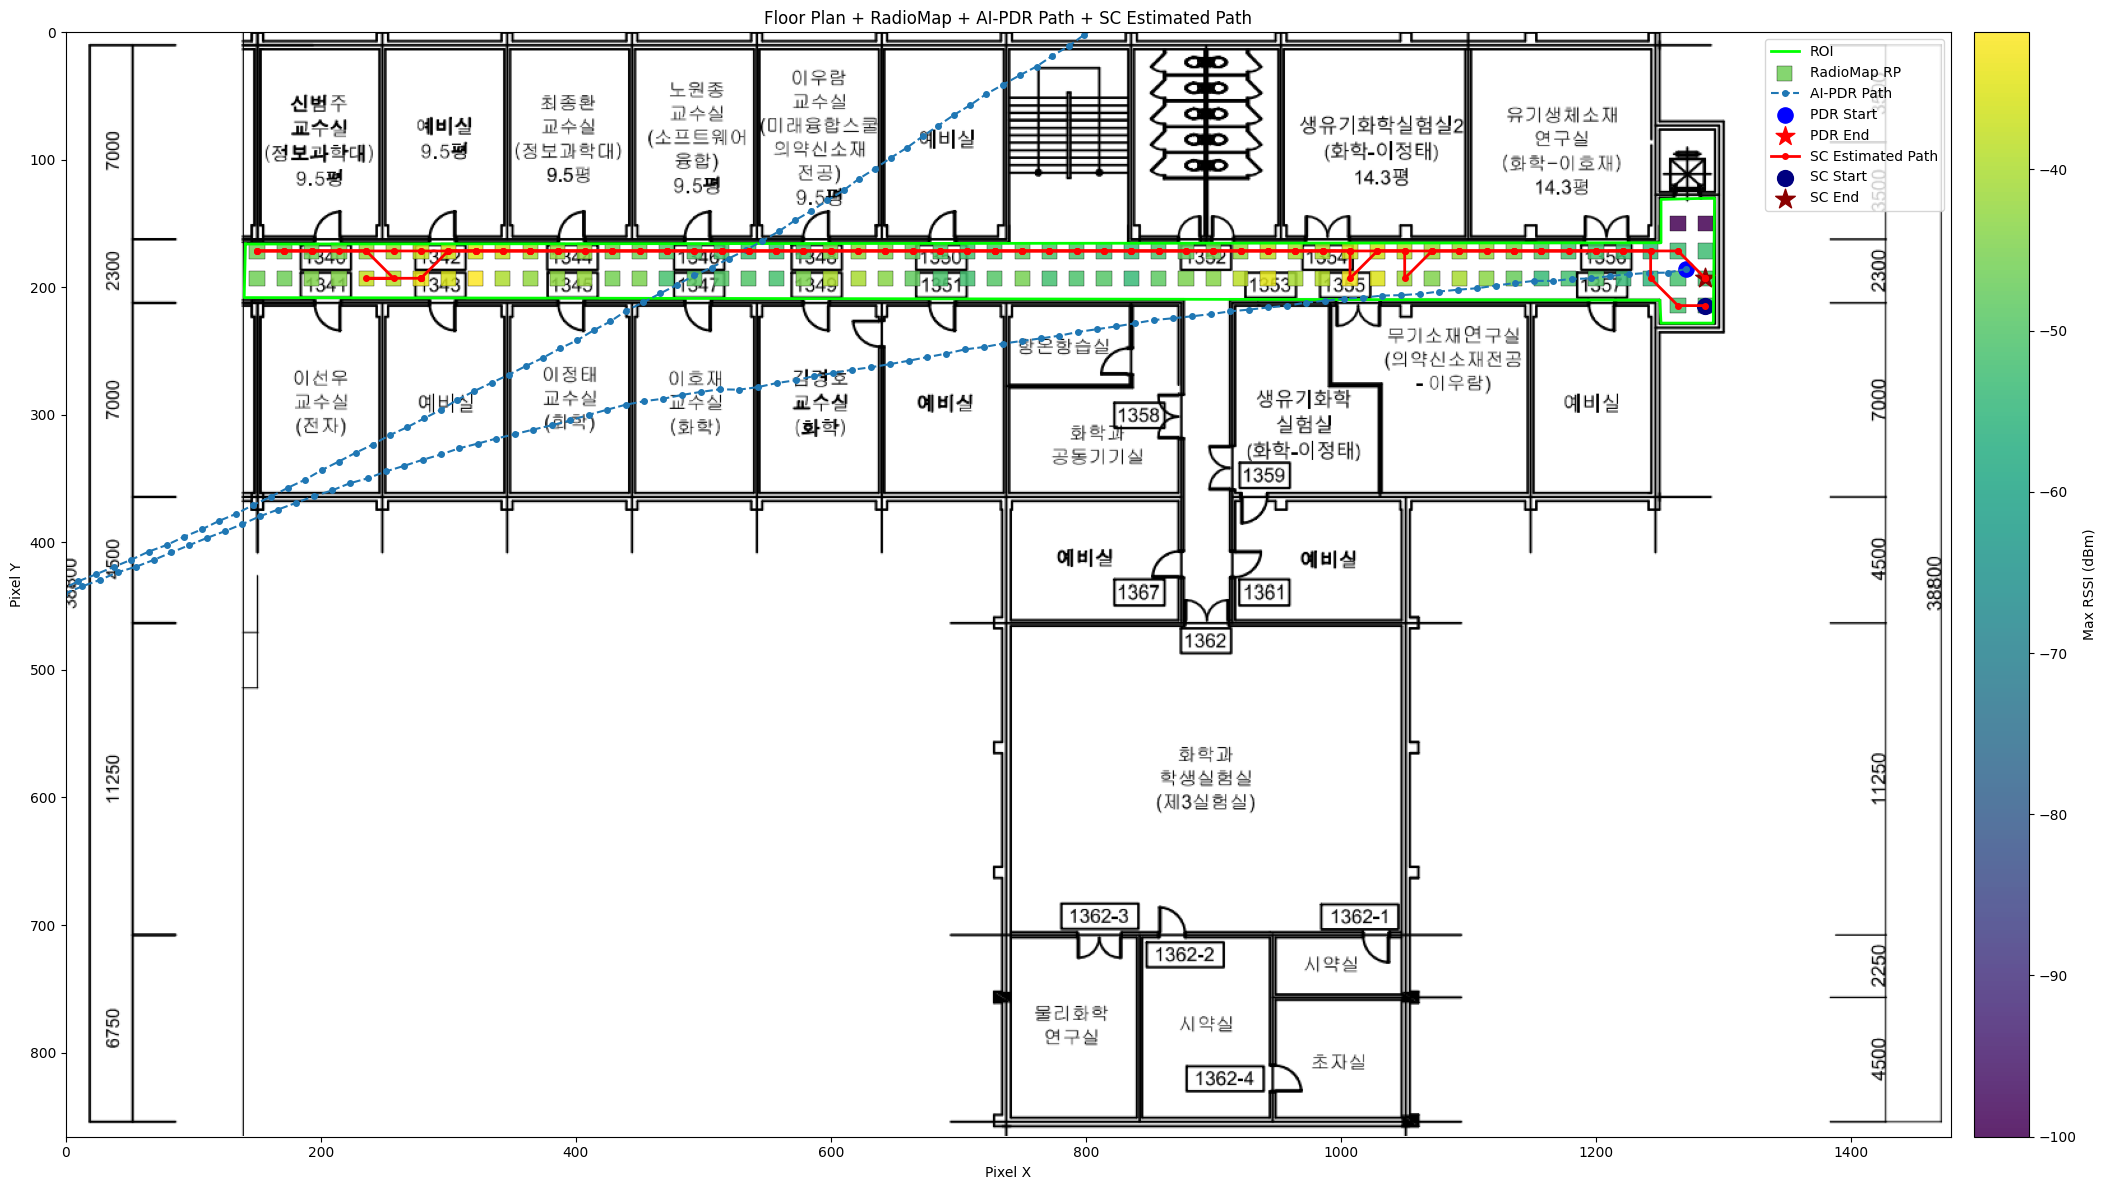

In [2]:
# ============================================================
# 도면 + RadioMap + AI-PDR Path + SC Estimated Path 시각화
# calibration.json 기반
# ============================================================

import json
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os


# ------------------------------------------------------------
# 1. calibration.json 로드
# ------------------------------------------------------------
CALIB_JSON_PATH = os.path.join(BASE_DIR, "temp_data", "calibration.json")

# 혹시 현재 폴더에 바로 있는 경우까지 대응
if not os.path.exists(CALIB_JSON_PATH):
    CALIB_JSON_PATH = os.path.join(BASE_DIR, "calibration.json")

with open(CALIB_JSON_PATH, "r", encoding="utf-8") as f:
    calib = json.load(f)

image_path = calib["image"]["path"]

# 상대경로면 BASE_DIR 기준으로 변환
if not os.path.isabs(image_path):
    image_path = os.path.join(BASE_DIR, image_path)

m_per_px = float(calib["calibration"]["m_per_px"])
px_per_m = float(calib["calibration"]["px_per_m"])

origin_x_px = float(calib["coordinate_system"]["origin_px"]["x"])
origin_y_px = float(calib["coordinate_system"]["origin_px"]["y"])

flip_y_before_save = bool(calib["coordinate_system"]["flip_y_before_save"])

print("[CALIB]")
print("image_path:", image_path)
print("m_per_px:", m_per_px)
print("px_per_m:", px_per_m)
print("flip_y_before_save:", flip_y_before_save)


# ------------------------------------------------------------
# 2. 한글 경로 안전 이미지 로드
# ------------------------------------------------------------
def imread_unicode(path):
    data = np.fromfile(path, dtype=np.uint8)
    img = cv2.imdecode(data, cv2.IMREAD_COLOR)
    return img


floor_img_bgr = imread_unicode(image_path)

if floor_img_bgr is None:
    raise FileNotFoundError(f"도면 이미지를 불러올 수 없습니다: {image_path}")

floor_img_rgb = cv2.cvtColor(floor_img_bgr, cv2.COLOR_BGR2RGB)

img_h, img_w = floor_img_rgb.shape[:2]


# ------------------------------------------------------------
# 3. meter 좌표 -> image pixel 좌표 변환 함수
# ------------------------------------------------------------
def meter_saved_to_pixel(x_m, y_m):
    """
    저장된 meter 좌표를 도면 이미지 pixel 좌표로 변환.

    calibration.json 기준:
    - 원점: 이미지 좌측 상단
    - x+: 오른쪽
    - raw y+: 아래쪽
    - 저장 시 flip_y_before_save=True이면 saved_y_m = -raw_y_m
    """

    x_m = np.asarray(x_m, dtype=float)
    y_m = np.asarray(y_m, dtype=float)

    # 저장된 y_m을 이미지 raw meter y로 복원
    if flip_y_before_save:
        raw_y_m = -y_m
    else:
        raw_y_m = y_m

    x_px = origin_x_px + (x_m / m_per_px)
    y_px = origin_y_px + (raw_y_m / m_per_px)

    return x_px, y_px


# ------------------------------------------------------------
# 4. RadioMap 좌표 준비
# ------------------------------------------------------------
# radioMap 좌표 컬럼 자동 판단
if {"x", "y"}.issubset(radioMap.columns):
    RM_X_COL = "x"
    RM_Y_COL = "y"
elif {"x_m", "y_m"}.issubset(radioMap.columns):
    RM_X_COL = "x_m"
    RM_Y_COL = "y_m"
else:
    raise ValueError("radioMap에 x/y 또는 x_m/y_m 컬럼이 없습니다.")

radio_x_m = radioMap[RM_X_COL].to_numpy(dtype=float)
radio_y_m = radioMap[RM_Y_COL].to_numpy(dtype=float)

radio_x_px, radio_y_px = meter_saved_to_pixel(radio_x_m, radio_y_m)

# RadioMap 배경 색상: 각 RP에서 가장 강한 RSSI
max_rssi = radioMap[common_aps].max(axis=1).to_numpy(dtype=float)


# ------------------------------------------------------------
# 5. AI-PDR Path pixel 변환
# ------------------------------------------------------------
pdr_x_px, pdr_y_px = meter_saved_to_pixel(
    pdr_path_aligned[:, 0],
    pdr_path_aligned[:, 1]
)


# ------------------------------------------------------------
# 6. SC Estimated Path pixel 변환
# ------------------------------------------------------------
estimated = np.asarray(estimated, dtype=float)

valid_est_mask = (
    ~np.isnan(estimated[:, 0]) &
    ~np.isnan(estimated[:, 1])
)

estimated_valid = estimated[valid_est_mask]

if len(estimated_valid) > 0:
    sc_x_px, sc_y_px = meter_saved_to_pixel(
        estimated_valid[:, 0],
        estimated_valid[:, 1]
    )
else:
    sc_x_px, sc_y_px = np.array([]), np.array([])


# ------------------------------------------------------------
# 7. ROI polygon도 같이 표시하고 싶으면 사용
# ------------------------------------------------------------
roi_px = None

try:
    roi_points_px = calib["roi"]["roi_points_px"]
    roi_px = np.array(
        [[p["x"], p["y"]] for p in roi_points_px],
        dtype=float
    )
except:
    roi_px = None


# ------------------------------------------------------------
# 8. 도면 + RadioMap + 경로 시각화
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(24, 12))

# 도면 배경
ax.imshow(floor_img_rgb)

# ROI polygon
if roi_px is not None and len(roi_px) >= 3:
    roi_closed = np.vstack([roi_px, roi_px[0]])

    ax.plot(
        roi_closed[:, 0],
        roi_closed[:, 1],
        color="lime",
        linewidth=2,
        label="ROI"
    )

# RadioMap RP
sc = ax.scatter(
    radio_x_px,
    radio_y_px,
    c=max_rssi,
    cmap="viridis",
    s=120,
    marker="s",
    edgecolor="black",
    linewidth=0.3,
    alpha=0.85,
    label="RadioMap RP"
)

cbar = fig.colorbar(sc, ax=ax, fraction=0.025, pad=0.01)
cbar.set_label("Max RSSI (dBm)")

# AI-PDR Path
ax.plot(
    pdr_x_px,
    pdr_y_px,
    "o--",
    markersize=4,
    linewidth=1.5,
    label="AI-PDR Path"
)

ax.scatter(
    pdr_x_px[0],
    pdr_y_px[0],
    c="blue",
    marker="o",
    s=120,
    label="PDR Start"
)

ax.scatter(
    pdr_x_px[-1],
    pdr_y_px[-1],
    c="red",
    marker="*",
    s=200,
    label="PDR End"
)

# SC Estimated Path
if len(sc_x_px) > 0:
    ax.plot(
        sc_x_px,
        sc_y_px,
        "r.-",
        markersize=8,
        linewidth=2.0,
        label="SC Estimated Path"
    )

    ax.scatter(
        sc_x_px[0],
        sc_y_px[0],
        c="navy",
        marker="o",
        s=130,
        label="SC Start"
    )

    ax.scatter(
        sc_x_px[-1],
        sc_y_px[-1],
        c="darkred",
        marker="*",
        s=220,
        label="SC End"
    )

# 보기 설정
ax.set_title("Floor Plan + RadioMap + AI-PDR Path + SC Estimated Path")
ax.set_xlabel("Pixel X")
ax.set_ylabel("Pixel Y")

# 이미지 좌표계 유지
ax.set_xlim(0, img_w)
ax.set_ylim(img_h, 0)

ax.legend(loc="upper right")
ax.grid(False)

plt.tight_layout()
plt.show()